# SHL Grammar Scoring: Model

Predicts the grammar score (1 to 5) of each test clip from the features made in the feature extraction notebook.

Five simple models, blended with a weighted average:

| Model | Input | What it sees |
|---|---|---|
| SVR | WavLM layer 21 (mean over time) | the audio |
| SVR | Whisper encoder layer 31 (mean and std over time) | the audio, at the level of words |
| Ridge | RoBERTa layer 19 | the transcript |
| Ridge | Qwen2.5-1.5B layer 17 | the transcript |
| Ridge | handcrafted features | syntax, grammar errors, acceptability, timing |

The layers and model settings were chosen by cross-validation in a separate experiment notebook. A larger stack of 13 models gave the same predictions, so only the five that carried weight are kept. Runs on CPU in a few minutes.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

DATA_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"
FEATURES_DIR = "/kaggle/input/datasets/codewiz19/features-shl"  # output of the feature extraction notebook
OUT_DIR = "/kaggle/working"
SEEDS = [0, 1, 2]

## 1. Load the features

In [2]:
clips = pd.read_csv(f"{FEATURES_DIR}/clips.csv")


def layer(name, i, dims=slice(None)):
    return np.asarray(np.load(f"{FEATURES_DIR}/emb_{name}.npy", mmap_mode="r")[:, i, dims], dtype=np.float32)


X = {
    "SVR · WavLM": layer("wavlm", 21, slice(0, 1024)),  # first half of the vector is the mean
    "SVR · Whisper": layer("whisper", 31),              # mean and std
    "Ridge · RoBERTa": layer("roberta", 19),
    "Ridge · Qwen": layer("qwen", 17),
    "Ridge · features": pd.read_csv(f"{FEATURES_DIR}/features.csv").to_numpy(np.float32),
}

is_test = clips["split"].eq("test").to_numpy()
# 37 training clips are labelled 0: pure noise that the raters could not score, so we leave them out
is_train = clips["split"].eq("train").to_numpy() & (clips["label"] > 0).to_numpy()
y = clips.loc[is_train, "label"].to_numpy()

print(f"train {is_train.sum()} | test {is_test.sum()}")
print({name: x.shape for name, x in X.items()})

train 732 | test 216
{'SVR · WavLM': (985, 1024), 'SVR · Whisper': (985, 2560), 'Ridge · RoBERTa': (985, 1024), 'Ridge · Qwen': (985, 1536), 'Ridge · features': (985, 45)}


## 2. Train the five models

5-fold cross-validation, repeated with 3 different shuffles. Every training clip gets an out-of-fold prediction (from models that never saw it), which gives an honest score. The test prediction is the average of all 15 fitted models.

In [3]:
def svr():
    return make_pipeline(StandardScaler(), SVR(C=10, epsilon=0.1))


def ridge():
    # the imputer fills the few missing handcrafted features (e.g. transcripts without punctuation)
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), RidgeCV(alphas=np.logspace(-1, 6, 15)))


MODELS = {name: svr if name.startswith("SVR") else ridge for name in X}


def rmse(pred):
    return np.sqrt(np.mean((np.clip(pred, 1, 5) - y) ** 2))


strata = np.clip(np.round(y), 2, 5).astype(int)  # stratify by score level (1 and 1.5 are rare, so merged into 2)
oof = {name: np.zeros(len(y)) for name in MODELS}
test = {name: np.zeros(is_test.sum()) for name in MODELS}

for seed in SEEDS:
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=seed).split(y, strata):
        for name, make_model in MODELS.items():
            x_train = X[name][is_train]
            model = make_model().fit(x_train[tr], y[tr])
            oof[name][va] += model.predict(x_train[va]) / len(SEEDS)
            test[name] += model.predict(X[name][is_test]) / (len(SEEDS) * 5)

for name in MODELS:
    print(f"{name:<17} CV RMSE {rmse(oof[name]):.4f}")

SVR · WavLM       CV RMSE 0.5213
SVR · Whisper     CV RMSE 0.5270
Ridge · RoBERTa   CV RMSE 0.6022
Ridge · Qwen      CV RMSE 0.6056
Ridge · features  CV RMSE 0.7056


## 3. Blend

A linear regression on the five out-of-fold predictions, with weights forced to be non-negative, decides how much each model counts. Its own score is measured with a separate cross-validation, so the blend is also judged on clips it did not see.

In [4]:
L = np.column_stack(list(oof.values()))
L_test = np.column_stack(list(test.values()))

blend_oof = np.zeros(len(y))
for tr, va in StratifiedKFold(5, shuffle=True, random_state=99).split(y, strata):
    blend_oof[va] = LinearRegression(positive=True).fit(L[tr], y[tr]).predict(L[va])

blender = LinearRegression(positive=True).fit(L, y)
final_test = np.clip(blender.predict(L_test), 1, 5)

print(f"blend            CV RMSE {rmse(blend_oof):.4f}")
print(f"predict the mean CV RMSE {y.std():.4f}")
print("weights:", {name: round(float(w), 3) for name, w in zip(MODELS, blender.coef_)})

blend            CV RMSE 0.4783
predict the mean CV RMSE 1.0137
weights: {'SVR · WavLM': 0.473, 'SVR · Whisper': 0.298, 'Ridge · RoBERTa': 0.152, 'Ridge · Qwen': 0.154, 'Ridge · features': 0.109}


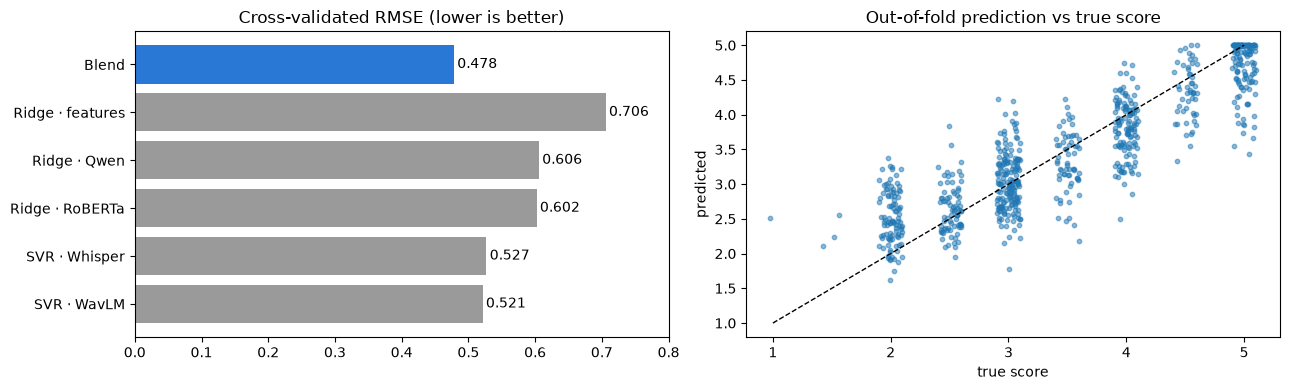

In [5]:
pred = np.clip(blend_oof, 1, 5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

scores = {**{name: rmse(p) for name, p in oof.items()}, "Blend": rmse(blend_oof)}
ax1.barh(list(scores), list(scores.values()), color=["#9a9a9a"] * len(oof) + ["#2a78d6"])
for i, v in enumerate(scores.values()):
    ax1.text(v + 0.005, i, f"{v:.3f}", va="center")
ax1.set(title="Cross-validated RMSE (lower is better)", xlim=(0, 0.8))

jitter = np.random.default_rng(0).uniform(-0.1, 0.1, len(y))
ax2.scatter(y + jitter, pred, s=10, alpha=0.5)
ax2.plot([1, 5], [1, 5], "k--", lw=1)
ax2.set(title="Out-of-fold prediction vs true score", xlabel="true score", ylabel="predicted")
plt.tight_layout()
plt.show()

## 4. Submission

In [6]:
submission = pd.DataFrame({"filename": clips.loc[is_test, "filename"].to_numpy(), "label": final_test})
assert submission["filename"].tolist() == pd.read_csv(f"{DATA_DIR}/test.csv")["filename"].tolist()
submission.to_csv(f"{OUT_DIR}/submission.csv", index=False)

print(f"{len(submission)} rows | mean {final_test.mean():.3f} | std {final_test.std():.3f}")
submission.head()

216 rows | mean 3.283 | std 0.827


,filename,label
0,audio_128.wav,2.933876
1,audio_156.wav,4.491688
2,audio_19.wav,4.587896
3,audio_108.wav,1.942970
4,audio_206.wav,2.257807
